In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models


2025-12-29 11:07:47.785977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767006467.967025      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767006468.025722      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767006468.489768      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767006468.489823      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767006468.489827      55 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = 96
BATCH_SIZE = 32


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/fer2013/train",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 80% train
    subset="training",
    seed=42,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/fer2013/train",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    validation_split=0.2,   # 20% validation
    subset="validation",
    seed=42,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/fer2013/test",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=BATCH_SIZE,
    shuffle=False
)



Found 28709 files belonging to 7 classes.
Using 22968 files for training.


I0000 00:00:1767006493.920159      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [4]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)


(32, 48, 48, 1)
(32,)


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])


In [6]:
def preprocess_train(image, label):
    # convert to RGB ONLY if needed
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = data_augmentation(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


def preprocess_val(image, label):
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


def preprocess_test(image, label):
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


train_ds = train_ds.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = (
    test_ds
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)


In [7]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(7, activation="softmax")
])


In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,              # stop if no improvement for 4 epochs
    restore_best_weights=True,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="mobinetnet_fer2013.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[early_stop, checkpoint]
)




Epoch 1/40


I0000 00:00:1767006512.270970     127 service.cc:152] XLA service 0x7adf28003940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767006512.271031     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1767006513.373723     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1767006518.416953     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2414 - loss: 2.3101
Epoch 1: val_loss improved from inf to 1.69994, saving model to mobinetnet_fer2013.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 62s 71ms/step - accuracy: 0.2414 - loss: 2.3098 - val_accuracy: 0.3686 - val_loss: 1.6999
Epoch 2/40
716/718 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3318 - loss: 1.8463
Epoch 2: val_loss improved from 1.69994 to 1.61999, saving model to mobinetnet_fer2013.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.3319 - loss: 1.8461 - val_accuracy: 0.3844 - val_loss: 1.6200
Epoch 3/40
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3584 - loss: 1.7123
Epoch 3: val_loss improved from 1.61999 to 1.57552, saving model to mobinetnet_fer2013.keras
718/718 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3584 - loss: 1.7122 - val_accuracy: 0.3984 - val_loss: 1.5755
Epoch 4/40
717/718 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3765 - loss: 1.6394
Epoch 4: val_loss improved from

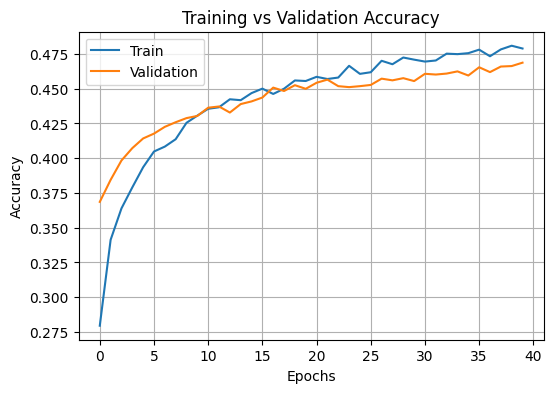

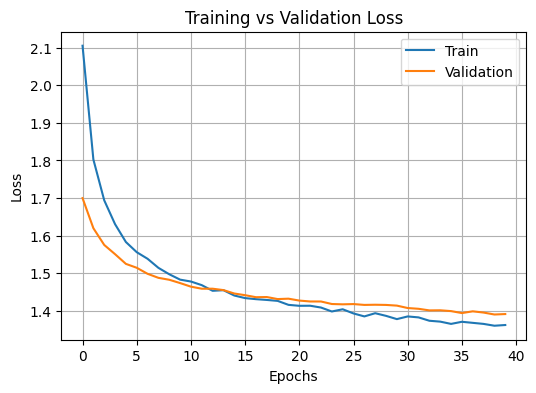

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)
plt.show()



In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4218 - loss: 1.4604
Test Accuracy: 47.83%
Test Loss: 1.3620


In [13]:
model.save("mobilenet_fer2013.keras")
